## PZ STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

pz=pd.read_csv('../stock_data/pz.csv') ## so it can be small letter. This is cool.
pz=pz.drop(columns=['high_price','low_price'])
pz.rename(columns={'trade_date':'date'},inplace=True)
pz['date']=pd.to_datetime(pz['date'])
pz['month']=pz['date'].dt.month
pz['quarter']=pz['date'].dt.quarter
pz['year']=pz['date'].dt.year

pz

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42802,PZ,2017-01-03,14.50,14.50,89666,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43362,PZ,2017-01-04,14.50,14.50,65225,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43472,PZ,2017-01-05,14.50,14.50,265303,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43582,PZ,2017-01-06,14.50,14.50,39651,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43672,PZ,2017-01-09,14.50,14.50,106805,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298120,PZ,2026-07-13,81.00,81.00,2149056,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298558,PZ,2026-07-14,81.00,81.00,1010041,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,298996,PZ,2026-07-15,81.00,81.00,998345,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299434,PZ,2026-07-16,80.95,80.95,1820892,2026-07-16T15:10:03.113936+00:00,7,3,2026


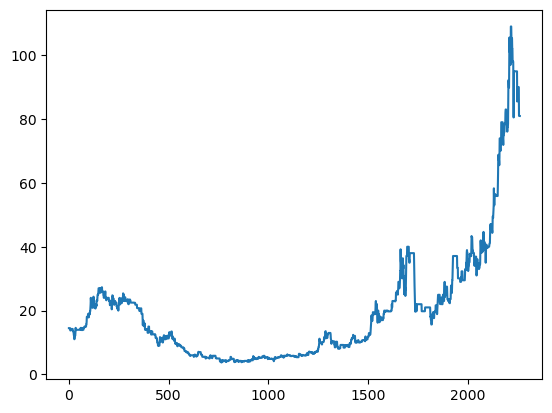

In [2]:
import matplotlib.pyplot as plt

plt.plot(pz['close_price'])
plt.show()

In [3]:
pz_end_month_df = (
    pz
    .sort_values("date")
    .groupby(pz["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

pz_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45372,PZ,2017-01-31,13.54,13.54,520760,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47193,PZ,2017-02-28,13.99,13.99,159160,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49309,PZ,2017-03-31,14.00,14.00,98030,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51137,PZ,2017-04-28,14.92,14.92,617948,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53059,PZ,2017-05-31,18.70,18.70,123629,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35357,PZ,2026-03-31,82.00,82.00,6820114,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281183,PZ,2026-04-30,105.55,105.55,4117859,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284249,PZ,2026-05-29,98.00,98.00,1310517,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294177,PZ,2026-06-30,85.50,85.50,1402025,2026-06-30T15:10:03.08168+00:00,6,2,2026


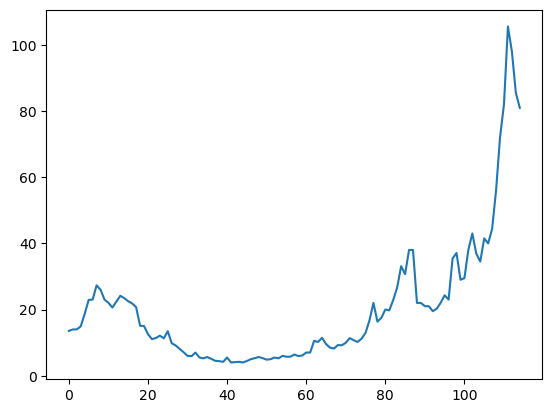

In [4]:
plt.plot(pz_end_month_df['close_price'])
plt.show()

In [5]:
pz_end_month_df['returns']=pz_end_month_df['close_price'].pct_change()*100
pz_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45372,PZ,2017-01-31,13.54,13.54,520760,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47193,PZ,2017-02-28,13.99,13.99,159160,2026-04-08T02:44:45.006295+00:00,2,1,2017,3.323486
2,49309,PZ,2017-03-31,14.00,14.00,98030,2026-04-08T02:45:42.281198+00:00,3,1,2017,0.071480
3,51137,PZ,2017-04-28,14.92,14.92,617948,2026-04-08T02:51:55.619599+00:00,4,2,2017,6.571429
4,53059,PZ,2017-05-31,18.70,18.70,123629,2026-04-08T02:52:57.421655+00:00,5,2,2017,25.335121
...,...,...,...,...,...,...,...,...,...,...,...
110,35357,PZ,2026-03-31,82.00,82.00,6820114,2026-03-31T15:00:02.085058+00:00,3,1,2026,13.888889
111,281183,PZ,2026-04-30,105.55,105.55,4117859,2026-04-30T15:00:02.170664+00:00,4,2,2026,28.719512
112,284249,PZ,2026-05-29,98.00,98.00,1310517,2026-05-29T15:00:02.455558+00:00,5,2,2026,-7.153008
113,294177,PZ,2026-06-30,85.50,85.50,1402025,2026-06-30T15:10:03.08168+00:00,6,2,2026,-12.755102


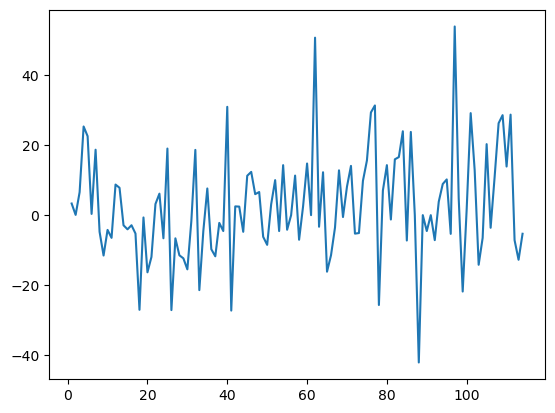

In [6]:
plt.plot(pz_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(pz_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(-10.006032570222514, 1.8305105615738322e-17, 0, 113, {'1%': -3.489589552580676, '5%': -2.887477210140433, '10%': -2.580604145195395}, 839.6046355539492)
stationary


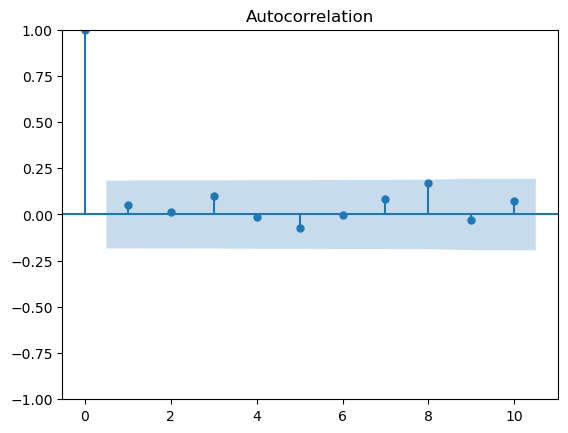

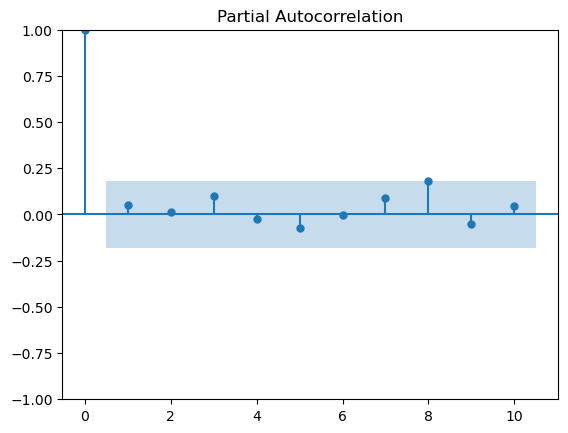

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(pz_end_month_df['returns'].dropna(), lags=10)
plot_pacf(pz_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=pz_end_month_df['close_price'][:-10]
test=pz_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -9.733403237078361]
[0, 0, 0, 0, 0, 1, -6.970073131046564]
[0, 0, 0, 0, 0, 2, -5.264959063213853]
[0, 0, 0, 0, 1, 0, -2.879780438617754]
[0, 0, 0, 0, 1, 1, -2.8605514339755365]
[0, 0, 0, 0, 1, 2, -2.008440895820948]
[0, 0, 0, 0, 2, 0, -2.6209859905518798]
[0, 0, 0, 0, 2, 1, -2.0580087914955096]
[0, 0, 0, 0, 2, 2, -1.3168333380182888]
[0, 0, 0, 1, 0, 0, -3.262009752375973]
[0, 0, 0, 1, 0, 1, -3.3262799694099776]
[0, 0, 0, 1, 0, 2, -2.312177112477932]
[0, 0, 0, 1, 1, 0, -2.8160893602407935]
[0, 0, 0, 1, 1, 1, -2.734015052964306]
[0, 0, 0, 1, 1, 2, -2.0165587166626513]
[0, 0, 0, 1, 2, 0, -1.4273678394601168]
[0, 0, 0, 1, 2, 1, -1.4524138018403372]
[0, 0, 0, 1, 2, 2, -1.3908969263781428]
[0, 0, 0, 2, 0, 0, -3.2717294317041103]
[0, 0, 0, 2, 0, 1, -3.221343296193128]
[0, 0, 0, 2, 0, 2, -3.042170829659552]
[0, 0, 0, 2, 1, 0, -2.3328830485566328]
[0, 0, 0, 2, 1, 1, -2.4485054398371497]
[0, 0, 0, 2, 1, 2, -2.121485963910954]
[0, 0, 0, 2, 2, 0, -1.463375256011374]
[0, 0, 0, 2,

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
0,0,0,0,0,0,0,-9.733403
27,0,0,1,0,0,0,-9.555126
54,0,0,2,0,0,0,-9.288712
425,1,2,0,2,0,2,-7.535168
416,1,2,0,1,0,2,-7.390692
...,...,...,...,...,...,...,...
196,0,2,1,0,2,1,-0.304734
465,1,2,2,0,2,1,-0.280619
707,2,2,2,0,2,1,-0.243020
681,2,2,1,0,2,1,-0.208143


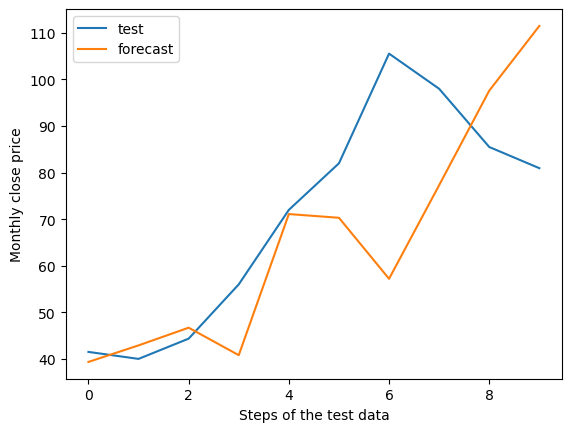

r2_score:  0.17299008377143987
rmse:  20.574790399907336
description:  count    115.000000
mean      20.106522
std       19.496756
min        4.000000
25%        6.700000
50%       13.990000
75%       23.000000
max      105.550000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=pz_end_month_df['close_price'][:-10]
y_test=pz_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(0,2,0), 
seasonal_order=(0,2,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', pz_end_month_df.close_price.describe())

Its not capturing the variations properly. Lets try the returns

In [12]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=pz_end_month_df['returns'].dropna()[:-10]
test=pz_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.43018076949284056]
[0, 0, 0, 0, 0, 1, -0.42685825611032513]
[0, 0, 0, 0, 0, 2, -0.3962980140098984]
[0, 0, 0, 0, 1, 0, -1.9702875617456637]
[0, 0, 0, 0, 1, 1, -0.2573954417826303]
[0, 0, 0, 0, 1, 2, -0.30400354201932656]
[0, 0, 0, 0, 2, 0, -10.463973772923929]
[0, 0, 0, 0, 2, 1, -2.369613925591786]
[0, 0, 0, 0, 2, 2, -0.6444302716891468]
[0, 0, 0, 1, 0, 0, -0.4266701793202554]
[0, 0, 0, 1, 0, 1, -0.42563376157647914]
[0, 0, 0, 1, 0, 2, -0.576214939398916]
[0, 0, 0, 1, 1, 0, -0.5208742244547555]
[0, 0, 0, 1, 1, 1, -0.3132219630775921]
[0, 0, 0, 1, 1, 2, -0.1799183945992826]
[0, 0, 0, 1, 2, 0, -3.4919302148360574]
[0, 0, 0, 1, 2, 1, -0.8990367824760572]
[0, 0, 0, 1, 2, 2, -0.7677526332777187]
[0, 0, 0, 2, 0, 0, -0.40602058225170956]
[0, 0, 0, 2, 0, 1, -0.3389978156581466]
[0, 0, 0, 2, 0, 2, -0.49724942111330916]
[0, 0, 0, 2, 1, 0, -0.4085281936489269]
[0, 0, 0, 2, 1, 1, -0.24142902827595414]
[0, 0, 0, 2, 1, 2, -0.23175186793216196]
[0, 0, 0, 2, 2, 0, -2.576778116681

In [13]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
168,0,2,0,0,2,0,-209.608863
177,0,2,0,1,2,0,-119.821950
411,1,2,0,0,2,0,-80.410689
426,1,2,0,2,1,0,-57.140838
669,2,2,0,2,1,0,-53.320222
...,...,...,...,...,...,...,...
482,1,2,2,2,1,2,-0.014645
365,1,1,1,1,1,2,-0.010742
239,0,2,2,2,1,2,-0.009838
608,2,1,1,1,1,2,-0.003212


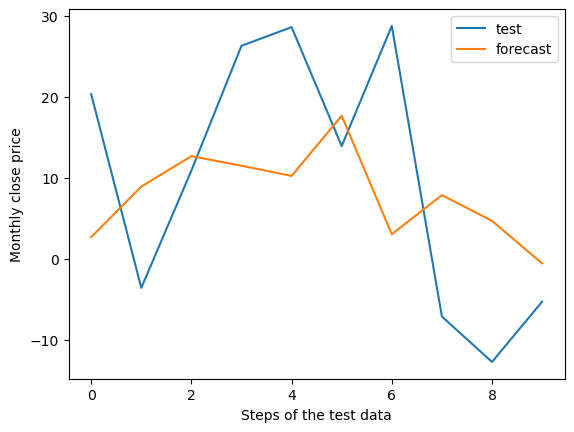

r2_score:  0.02640610888033945
rmse:  15.009221637703078
description:  count    114.000000
mean       2.715571
std       15.349696
min      -42.105263
25%       -5.983466
50%        0.000000
75%       12.017263
max       53.913043
Name: returns, dtype: float64


In [14]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=pz_end_month_df['returns'].dropna()[:-10]
y_test=pz_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(1,2,2), 
seasonal_order=(1,1,2,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', pz_end_month_df.returns.dropna().describe())

Very horrible. We will work with close_price
